# Neural network for image classification 

Example of a simple neural network for image classification using TensorFlow and Keras. Image classificiation for Dogs and Cats dataset.

Approach taken - extract all the pixels

### Importing the libraries

In [ ]:
import cv2
import numpy as np
import os
import zipfile
import tensorflow as tf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from google.colab.patches import cv2_imshow
from google.colab import drive
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

tf.__version__

'2.20.0'

### Extracting pixels from images

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = '/content/drive/My Drive/Colab Notebooks/Computer Vision Masterclass_Udemy/Training_Material/Datasets/cat_dog_1.zip'
zip_object = zipfile.ZipFile(file = path, mode = 'r')
zip_object.extractall('./')
zip_object.close()

In [ ]:
directory_train = '/content/cat_dog_1/train'
directory_test = '/content/cat_dog_1/test'
files_train = [os.path.join(directory_train, f) for f in sorted(os.listdir(directory_train))]
files_test = [os.path.join(directory_test, f) for f in sorted(os.listdir(directory_test))]

In [ ]:
height, width = 128, 128

In [ ]:
images = []
classes = []
for image_path in files_train:
  try:
    image = cv2.imread(image_path)
    (H, W) = image.shape[:2]
  except:
    continue

  image = cv2.resize(image, (width, height))
  image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
  
  cv2_imshow(image)
  
  image = image.ravel()
  print(image.shape)

  images.append(image)

  image_name = os.path.basename(os.path.normpath(image_path))
  if image_name.startswith('c'):
    # Cat
    class_name = 0
  else:
    # Dog
    class_name = 1

  classes.append(class_name)
  print(class_name)

In [ ]:
X_train = np.asarray(images)
y_train = np.asarray(classes)

In [ ]:
X_train.shape, y_train.shape

((4000, 16384), (4000,))

### Test Dataset

In [ ]:
images = []
classes = []
for image_path in files_test:
  try:
    image = cv2.imread(image_path)
    (H, W) = image.shape[:2]
  except:
    continue

  image = cv2.resize(image, (width, height))
  image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
  
  cv2_imshow(image)
  
  image = image.ravel()
  print(image.shape)

  images.append(image)

  image_name = os.path.basename(os.path.normpath(image_path))
  if image_name.startswith('c'):
    # Cat
    class_name = 0
  else:
    # Dog
    class_name = 1

  classes.append(class_name)
  print(class_name)

In [ ]:
X_test = np.asarray(images)
y_test = np.asarray(classes)

In [ ]:
X_test.shape, y_test.shape

((1000, 16384), (1000,))

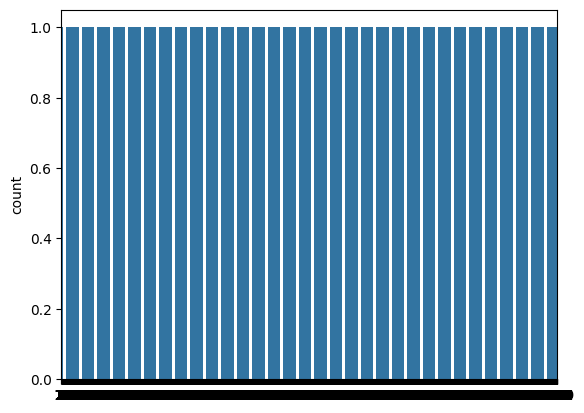

In [ ]:
sns.countplot(y_train);

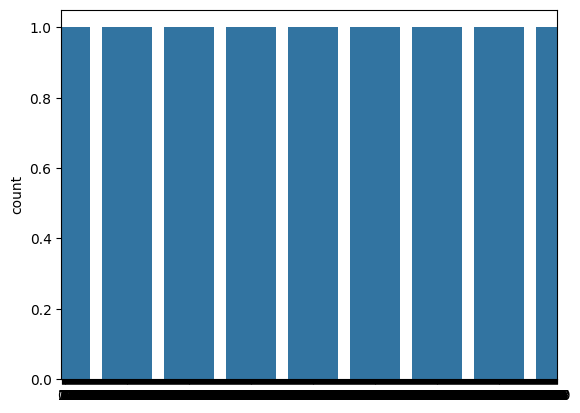

In [ ]:
sns.countplot(y_test);

### Normalizing the data

In [ ]:
X_train[0].max(), X_train[0].min()

(np.uint8(236), np.uint8(1))

In [ ]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
X_train[0].max(), X_train[0].min()

(np.float64(0.9254901960784314), np.float64(0.0))

In [ ]:
X_train[0].max(), X_train[0].min()

(np.float64(0.9254901960784314), np.float64(0.0))

### Build and train neural network

In [ ]:
(16384 + 2) / 2

8193.0

In [ ]:
# 16384 -> 8193 -> 8193 -> 1
network1 = tf.keras.models.Sequential()
network1.add(tf.keras.layers.Dense(input_shape=(16384,), units=8193, activation='relu'))
network1.add(tf.keras.layers.Dense(units=8193, activation = 'relu'))
network1.add(tf.keras.layers.Dense(units = 1, activation = 'sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
network1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8193)           │   134,242,305 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8193)           │    67,133,442 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         8,194 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 201,383,941 (768.22 MB)

 Trainable params: 201,383,941 (768.22 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# https://keras.io/api/optimizers/
# https://keras.io/api/losses/
network1.compile(optimizer='Adam', loss='binary_crossentropy', metrics = ['accuracy'])

In [ ]:
history = network1.fit(X_train, y_train, epochs=10)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 467s 4s/step - accuracy: 0.5073 - loss: 6.9681
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 469s 4s/step - accuracy: 0.5505 - loss: 0.7060
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 503s 4s/step - accuracy: 0.5540 - loss: 0.6947
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 490s 4s/step - accuracy: 0.5415 - loss: 0.6931
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 471s 4s/step - accuracy: 0.5437 - loss: 0.6890
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 504s 4s/step - accuracy: 0.5263 - loss: 0.6907
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 472s 4s/step - accuracy: 0.5695 - loss: 0.6757
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 501s 4s/step - accuracy: 0.5470 - loss: 0.6942
Epoch 9/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 456s 4s/step - accuracy: 0.5840 - loss: 0.6689
Epoch 10/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 512s 4s/step - accuracy: 0.5332 - loss: 0.6898


### Evaluate Neural Network

In [ ]:
history.history.keys()

dict_keys(['accuracy', 'loss'])

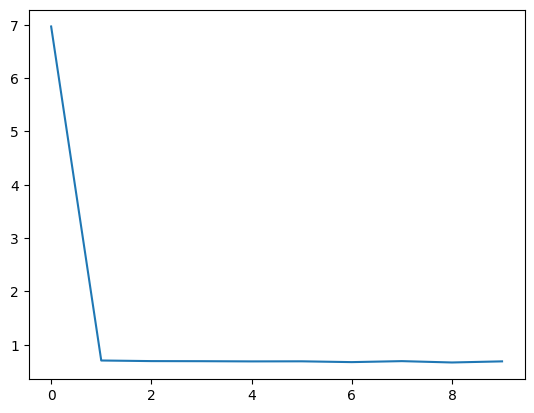

In [ ]:
plt.plot(history.history['loss']);

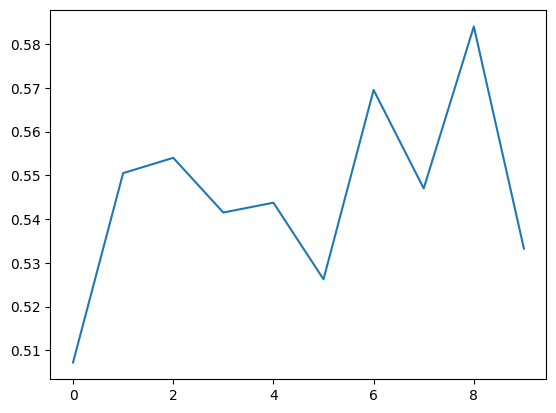

In [ ]:
plt.plot(history.history['accuracy']);

In [ ]:
X_test.shape

(1000, 16384)

In [ ]:
predictions = network1.predict(X_test)
predictions
# 0 False - Bart
# 1 True  - Homer

32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 420ms/step


array([[0.50981694],
       [0.50981694],
       [0.50981694],
       [0.50981694],
       [0.50981694],
       [0.50981694],
       [0.50981694],
       [0.50981694],
       [0.50981694],
       [0.50981694],
       [0.50981694],
       [0.50981694],
       [0.50981694],
       [0.50981694],
       [0.50981694],
       [0.50981694],
       [0.50981694],
       [0.50981694],
       [0.50981694],
       [0.50981694],
       [0.50981694],
       [0.50981694],
       [0.50981694],
       [0.50981694],
       [0.50981694],
       [0.50981694],
       [0.50981694],
       [0.50981694],
       [0.50981694],
       [0.50981694],
       [0.50981694],
       [0.50981694],
       [0.50981694],
       [0.50981694],
       [0.50981694],
       [0.50981694],
       [0.50981694],
       [0.50981694],
       [0.50981694],
       [0.50981694],
       [0.50981694],
       [0.50981694],
       [0.50981694],
       [0.50981694],
       [0.50981694],
       [0.50981694],
       [0.50981694],
       [0.509

In [ ]:
predictions = (predictions > 0.5)
predictions

array([[ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [

In [ ]:
y_test

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [ ]:
accuracy_score(y_test, predictions)

0.501

In [ ]:
cm = confusion_matrix(y_test, predictions)
cm

array([[  1, 499],
       [  0, 500]])

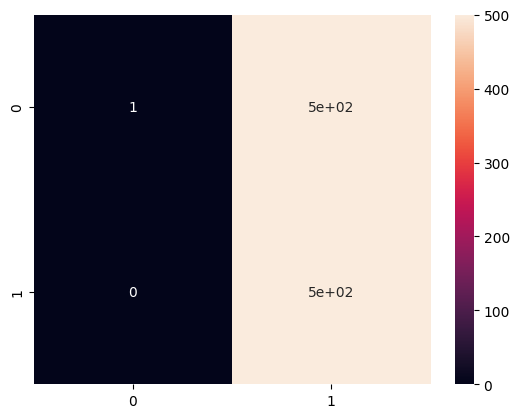

In [ ]:
sns.heatmap(cm, annot=True);

In [ ]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       1.00      0.00      0.00       500
           1       0.50      1.00      0.67       500

    accuracy                           0.50      1000
   macro avg       0.75      0.50      0.34      1000
weighted avg       0.75      0.50      0.34      1000

